# Homework 2 — Regression — ML Zoomcamp 2026 cohort

Predicting `fuel_efficiency_mpg` from engine displacement, horsepower, vehicle weight and model year with linear regression. Questions: `homework2_2026.md`.

Models use the lecture's numpy normal equation (lessons 07 and 13), as the homework requires, not sklearn's `Ridge`, which penalises differently.

## Setup and dataset


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

df_raw = pd.read_csv('car_fuel_efficiency_2026.csv')
df_raw.shape
df_raw.dtypes
df_raw.head()



,model_year,origin,fuel_type,drivetrain,num_doors,engine_displacement,num_cylinders,horsepower,vehicle_weight,acceleration,fuel_efficiency_mpg
0,2006,Europe,Gasoline,Front-wheel drive,4,2180,6,243.0,3870,NaN,31.9
1,2008,Europe,Diesel,Front-wheel drive,4,2390,6,272.0,4210,NaN,31.3
2,1996,Asia,Gasoline,Front-wheel drive,5,2320,6,267.0,4240,17.3,27.5
3,1989,Europe,Gasoline,Front-wheel drive,4,2130,6,258.0,4490,18.7,28.5
4,1994,USA,Diesel,Front-wheel drive,3,2580,7,304.0,4510,17.5,31.0


In [2]:
COLS = ['engine_displacement', 'horsepower', 'vehicle_weight', 'model_year', 'fuel_efficiency_mpg']
df = df_raw[COLS].copy()
df.head()

,engine_displacement,horsepower,vehicle_weight,model_year,fuel_efficiency_mpg
0,2180,243.0,3870,2006,31.9
1,2390,272.0,4210,2008,31.3
2,2320,267.0,4240,1996,27.5
3,2130,258.0,4490,1989,28.5
4,2580,304.0,4510,1994,31.0


### EDA — does `fuel_efficiency_mpg` have a long tail?

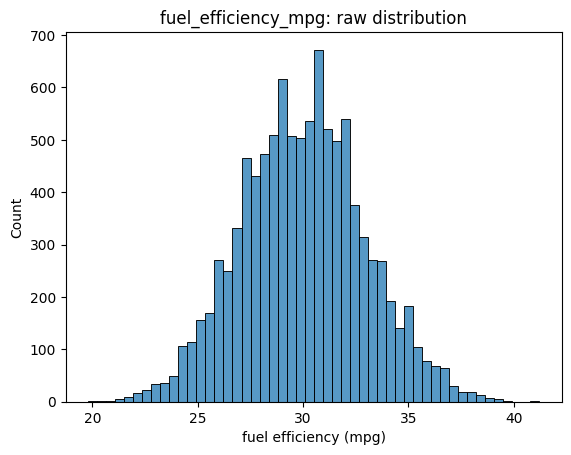

In [3]:
sns.histplot(df.fuel_efficiency_mpg, bins=50)
plt.xlabel('fuel efficiency (mpg)')
plt.title('fuel_efficiency_mpg: raw distribution')
plt.show()


In [4]:
df.fuel_efficiency_mpg.describe()

count    10000.000000
mean        29.997700
std          2.930245
min         19.800000
25%         28.000000
50%         30.000000
75%         31.900000
max         41.200000
Name: fuel_efficiency_mpg, dtype: float64

No. The target is roughly symmetric (mean ≈ median ≈ 30 mpg) and spans only about 2× (19.8 to 41.2), so unlike the lecture's car prices it needs no log transform, and every RMSE below is in mpg.

## Helper functions

One training function covers both questions: with `r = 0` it is the plain normal equation (Q3, Q5); with `r > 0` it adds `r` to the diagonal of XᵀX (Q4, Q6).

In [5]:
TARGET = 'fuel_efficiency_mpg'


def prepare_X(df, fill_value):
    """Features only (target dropped), missing values replaced by fill_value."""
    return df.drop(columns=TARGET).fillna(fill_value).values


def train_linear_regression(X, y, r=0.0):
    """Normal equation with optional ridge term: w = (X'X + rI)^-1 X'y. r=0 → plain OLS."""
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])

    XTX = X.T.dot(X) + r * np.eye(X.shape[1])
    w_full = np.linalg.inv(XTX).dot(X.T).dot(y)

    return w_full[0], w_full[1:]


def rmse(y, y_pred):
    return np.sqrt(((y - y_pred) ** 2).mean())


## Q1. Which column has missing values?

In [6]:
na= df.isna().sum()
na[na>0]

horsepower    877
dtype: int64

**Answer: `horsepower`** (877 missing).

## Q2. Median of `horsepower`

In [7]:
df.horsepower.median()


np.float64(254.0)

**Answer: 254**

## Split — 60/20/20, shuffled

The homework's split code, wrapped in a function of `seed`: 42 by default, 0–9 in Q5, 9 in Q6.

In [8]:
def split(df, seed=42):
    """Return df_train, df_val, df_test — 60/20/20, shuffled with the given seed."""
    n = len(df)
    n_val = int(n * 0.2)
    n_test = int(n * 0.2)
    n_train = n - n_val - n_test

    np.random.seed(seed)
    idx = np.arange(n)
    np.random.shuffle(idx)

    df_train = df.iloc[idx[:n_train]].reset_index(drop=True)
    df_val = df.iloc[idx[n_train:n_train + n_val]].reset_index(drop=True)
    df_test = df.iloc[idx[n_train + n_val:]].reset_index(drop=True)

    return df_train, df_val, df_test


## Q3. Fill NAs with 0 or with the mean?

Train without regularization, evaluate on validation, `round(score, 3)`. The mean is computed on the training split only.

In [9]:
df_train, df_val, df_test = split(df)            # seed 42
y_train = df_train[TARGET].values
y_val = df_val[TARGET].values

mean_hp = df_train.horsepower.mean()             # learned on train only

for name, fill in [('zero', 0), ('mean', mean_hp)]:
    w0, w = train_linear_regression(prepare_X(df_train, fill), y_train)
    y_pred = w0 + prepare_X(df_val, fill).dot(w)
    print(name, round(rmse(y_val, y_pred), 3))

zero 2.205
mean 2.202


**Answer: with mean** (validation RMSE 2.202 vs 2.205).

## Q4. Best `r` for regularized regression

Fill NAs with 0, try `r` in `[0, 0.01, 0.1, 1, 5, 10, 100]`, round to 4 decimals, smallest `r` wins ties.

In [10]:
reg = [0, 0.01, 0.1, 1, 5, 10, 100]
fill = 0

X_train = prepare_X(df_train, fill)     # doesn't depend on r → build once
X_val = prepare_X(df_val, fill)

results = []
for r in reg:
    w0, w = train_linear_regression(X_train, y_train, r=r)
    score = round(rmse(y_val, w0 + X_val.dot(w)), 4)
    results.append((score, r))

for score, r in sorted(results):
    print(f"{r:>6} {score:.4f}")

     0 2.2053
  0.01 2.2058
   0.1 2.2241
     1 2.3492
     5 2.4094
    10 2.4195
   100 2.4292


**Answer: r = 0** (validation RMSE 2.2053). With four well-conditioned numeric features there is nothing for regularisation to stabilise, so larger `r` only adds bias.

## Q5. How much does the seed move the score?

Seeds 0–9, fill NAs with 0, no regularization; standard deviation of the validation RMSEs, `round(std, 3)`.

In [11]:
fill = 0
scores = []

for seed in np.arange(10):
    df_train, df_val, df_test = split(df, seed=seed)
    y_train = df_train[TARGET].values
    y_val = df_val[TARGET].values

    X_train = prepare_X(df_train, fill)
    X_val = prepare_X(df_val, fill)

    w0, w = train_linear_regression(X_train, y_train)      # r defaults to 0 → no regularization
    scores.append(rmse(y_val, w0 + X_val.dot(w)))

print(np.round(scores, 3))
print('std:', round(np.std(scores), 3))


[2.239 2.202 2.163 2.204 2.202 2.246 2.27  2.191 2.217 2.207]
std: 0.029


**Answer: 0.029.** That spread is about ten times the Q3 gap (0.003) and sixty times the Q4 gap (0.0005), so those winners are specific to seed 42. Comparing settings reliably needs several splits (cross-validation), not one.

## Q6. Test RMSE

Seed 9, train on train + validation, fill NAs with 0, `r = 0.001`.

In [12]:
df_train, df_val, df_test = split(df, seed=9)
fill = 0

X_full_train = np.concatenate([prepare_X(df_train, fill), prepare_X(df_val, fill)])
y_full_train = np.concatenate([df_train[TARGET].values, df_val[TARGET].values])

X_test = prepare_X(df_test, fill)
y_test = df_test[TARGET].values

w0, w = train_linear_regression(X_full_train, y_full_train, r=0.001)
score = rmse(y_test, w0 + X_test.dot(w))
print(round(score, 3))


2.236


**Answer: 2.236**